In [22]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import igraph
from igraph import Graph, plot

# Original COVID simulation

In [3]:
R0_original = 2.75
k_original=0.1
simulations = 10000

In [4]:
def transmission_chain(active_cases,R0,k):
    new_cases = np.zeros((active_cases,1))
    for x in range(6):
        for y in range(active_cases):
            new_cases[y] = np.random.negative_binomial(k,k/(k+R0))
        active_cases = int(sum(new_cases))
        new_cases = np.zeros((active_cases,1))
    return active_cases

In [5]:
C_original = np.ones((simulations,1))
for a in range(simulations):
    C_original[a] = transmission_chain(1,R0_original,k_original)

Text(0.5, 1.0, 'Original COVID Strain Outbreak')

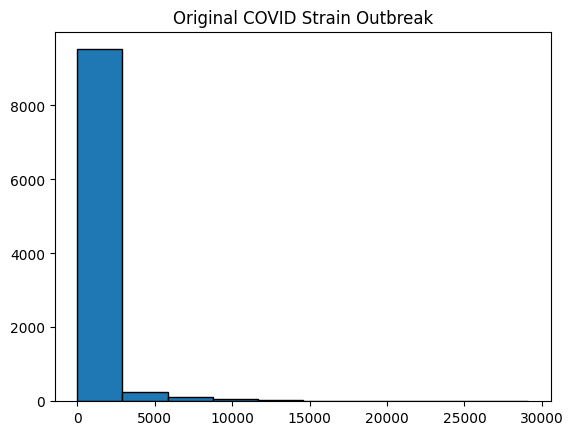

In [8]:
plt.hist(C_original,edgecolor = 'black')
plt.title('Original COVID Strain Outbreak')

In [9]:
p_original = sum(C_original<10)/simulations
print(np.format_float_positional(p_original, trim='-'))

0.8467


In [10]:
max(C_original)

array([29121.])

# Delta COVID Strain

In [11]:
R0_delta = 5
k_delta=0.5

In [12]:
C_delta = np.zeros((simulations,1))
for a in range(simulations):
    C_delta[a] = transmission_chain(1,R0_delta,k_delta)

Text(0, 0.5, 'Frequency')

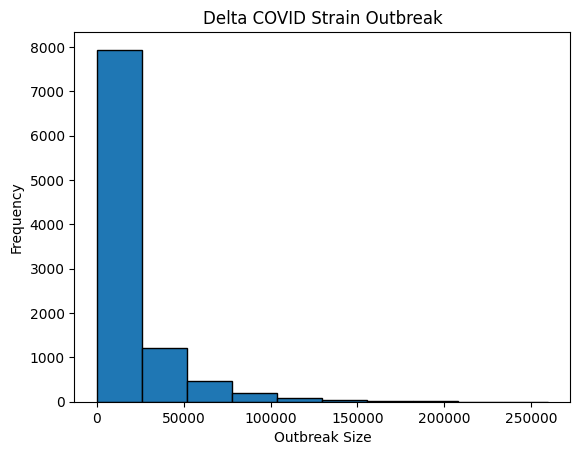

In [15]:
plt.hist(C_delta,edgecolor = 'black')
plt.title('Delta COVID Strain Outbreak')
plt.xlabel('Outbreak Size')
plt.ylabel('Frequency')

In [14]:
p_delta = sum(C_delta==0)/simulations
print(np.format_float_positional(p_delta, trim='-'))

0.3684


In [105]:
max(C_delta)

array([259697.])

# Calculating Extinction Probability

In [237]:
def bisect(f,a,b,tol):
    while np.abs(a-b)>tol:
        n = f(b)
        c = np.mean([a,b])
        p = f(c)
        if np.sign(p) == np.sign(n):
            b = c
        else:
            a = c
    return c

In [351]:
g_original = lambda q: (1+(R0_original*(1-q)/k_original))**(-k_original)-q

In [352]:
bisect(g_original,0,0.99,10**(-9))

0.8486091075371951

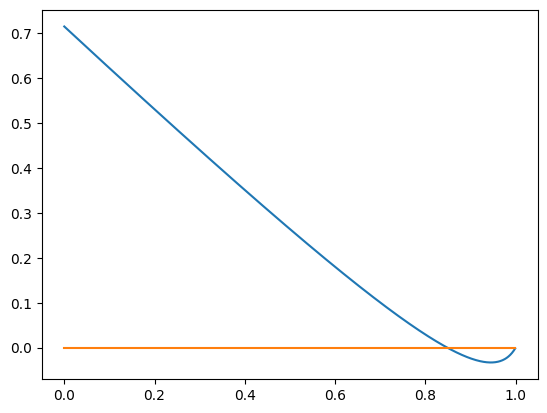

In [353]:
Q = np.arange(0,1,0.001)
plt.plot(Q,g(Q))
plt.plot(Q,np.zeros((len(Q),1)))

In [356]:
g_delta = lambda q: (1+(R0_delta*(1-q)/k_delta))**(-k_delta)-q

In [357]:
bisect(g_delta,0,0.99,10**(-9))

0.3701562120113522

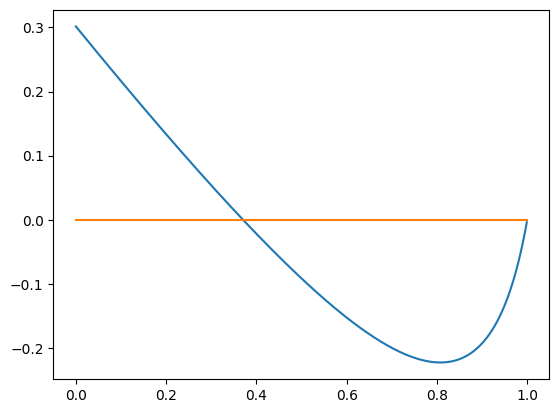

In [358]:
Q = np.arange(0,1,0.001)
plt.plot(Q,g_delta(Q))
plt.plot(Q,np.zeros((len(Q),1)))

# Visualising Chain Transmission

In [400]:
g = Graph()
print(g)

IGRAPH U--- 0 0 --


In [401]:
g.add_vertices(2)

In [402]:
print(g)

IGRAPH U--- 2 0 --


In [487]:
g = Graph([(0,x) for x in range(10)])

In [488]:
print(g)

IGRAPH U--- 10 10 --
+ edges:
0--0 0--1 0--2 0--3 0--4 0--5 0--6 0--7 0--8 0--9


In [489]:
layout = g.layout_reingold_tilford(root=[0])

<Axes: >

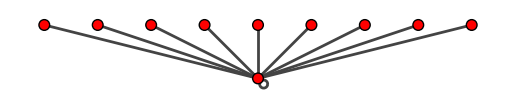

In [490]:
fig,ax= plt.subplots()
igraph.plot(g,layout=layout,target=ax)



<Axes: >

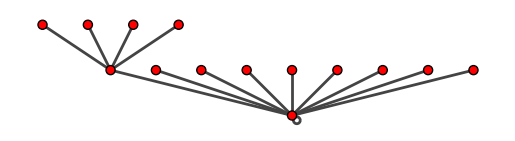

In [497]:
layout = g.layout("rt", 0)
fig,ax= plt.subplots()
igraph.plot(g,layout=layout,target=ax)

In [103]:
def transmission_visual(R0,k):
    g = Graph()
    g.add_vertices(1)
    total_cases = 1
    T = 1
    G = 1
    for x in range(6):
        if G == 0:
            break
        elif T>1000:
            break
        gen_cases = 0
        for s in range(T-G,T):
            m = np.random.negative_binomial(k,k/(k+R0))
            g.add_vertices(m)
            g.add_edges([(s,t) for t in range(total_cases,total_cases+m)])
            gen_cases += m
            total_cases += m
        G = gen_cases
        T = total_cases
    layout = g.layout("rt", 0)
    fig,ax= plt.subplots()
    plot(g,layout=layout,target=ax,bbox=(1200,1200))

In [100]:
for j in range(10):
    transmission_visual(R0_original,k_original)

TypeError: transmission_visual() got an unexpected keyword argument 'bbox'

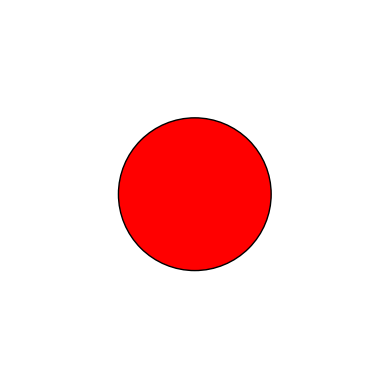

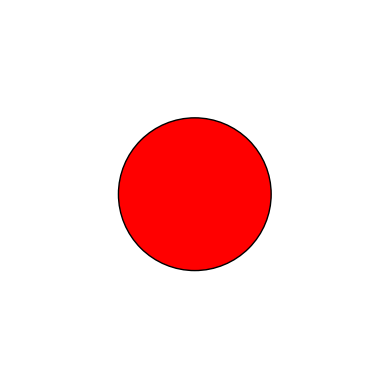

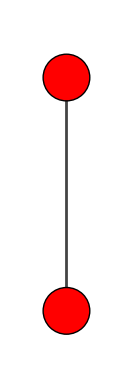

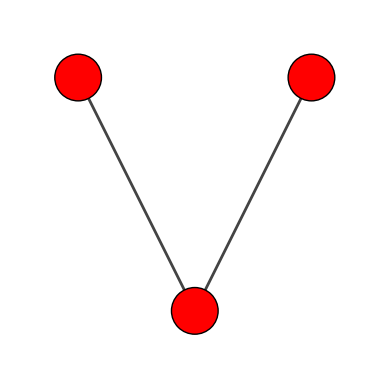

In [104]:
for j in range(10):
    transmission_visual(R0_delta,k_delta)